# Basic Python
## Part 1: Logic and String Manipulation

**1.a The DNA Helix Printer**
Write a function `print_helix(n, turns)` where `n` is the width of the helix and `turns` is the number of full cycles. The helix is formed by two strands.
* The strands oscillate using a sine-wave-like pattern.
* The characters for the strands should cycle through `A, C, G, T`.
* **Constraint:** You must handle the spacing dynamically.

**Example Output (`n=4, turns=1`):**
```text
A      A
 C    C
  G  G
   TT
  A  A
 C    C
G      G

In [1]:
def print_helix(n, turns):
    chars = ["A", "C", "G", "T"]
    cycle = 2*n - 1
    total = turns * cycle
    max_shift = n - 1

    for line in range(total):
        ch = chars[line % 4]
        p = line % cycle

        # a-pattern: 0,1,...,max_shift,...,1,0
        a = p if p <= max_shift else (2*max_shift - p)

        b = 2 * (max_shift - a)

        print(" " * a + ch + " " * b + ch)



# Test
print_helix(6, 2)

A          A
 C        C
  G      G
   T    T
    A  A
     CC
    G  G
   T    T
  A      A
 C        C
G          G
T          T
 A        A
  C      C
   G    G
    T  T
     AA
    C  C
   G    G
  T      T
 A        A
C          C


**1.b The Custom Sorter**
Write a function `sort_strings(s_list)` that takes a list of strings and sorts them based on the following priority rules:
1.  **Primary:** Length of the string (Ascending).
2.  **Secondary:** Number of distinct vowels (a, e, i, o, u) present in the string (Descending).
3.  **Tertiary:** Alphabetical order (Ascending).

**Example:**
Input: `["apple", "banana", "kiwi", "sky", "aieou", "z"]`
Output: `['z', 'sky', 'kiwi', 'aieou', 'apple', 'banana']`

In [2]:
def sort_strings(s_list):
    vowels = set("aeiou")

    def key(s):
        length = len(s)
        distinct_vowels = len(set(s) & vowels)
        return (length, -distinct_vowels, s)

    return sorted(s_list, key=key)


# Test
data = ["apple", "banana", "kiwi", "sky", "aieou", "z"]
print(sort_strings(data))

['z', 'sky', 'kiwi', 'aieou', 'apple', 'banana']


## Part 2: Working with Data

Consider that you are processing raw data from a sensor in a physics lab. The sensor is noisy and occasionally malfunctions.

**Task:**
1.  Read the file ```sensor_logs.csv``` **without using Pandas**.
2.  **Filter:** Ignore rows where `status` is "ERR" OR `voltage` > 10.0.
3.  **Analysis:** Calculate the **Mean** and **Standard Deviation** for each sensor.

In [ ]:
import math

def analyze_sensors(filename):
    sensors = {}

    with open(filename, "r") as f:
        next(f)  # skip header

        for line in f:
            timestamp, sensor_id, voltage_str, status = line.strip().split(",")

            voltage = float(voltage_str)

            # strip and lower give more predictabe output
            # im assuming no formatting issues nahi toh crash ho jayega
            if status.strip().lower() == "err" or voltage > 10.0:
                continue

            if sensor_id not in sensors:
                sensors[sensor_id] = []
            sensors[sensor_id].append(voltage)

    for sensor_id, values in sensors.items():
        if not values:
            continue

        n = len(values)
        mean = sum(values) / n
        variance = sum((v - mean) ** 2 for v in values) / n
        std = math.sqrt(variance)

        print(f"Sensor {sensor_id}:")
        # print(f"  Count = {n}")
        print(f"  Mean  = {mean:.3f}")
        print(f"  Std   = {std:.3f}\n")


# Test
analyze_sensors("sensor_log.csv")


Sensor S3:
  Mean  = 3.927
  Std   = 0.577

Sensor S1:
  Mean  = 4.026
  Std   = 0.543

Sensor S2:
  Mean  = 4.055
  Std   = 0.583

Sensor S4:
  Mean  = 3.973
  Std   = 0.584



## SciPy

### Task 1

Find the positive root of the transcendental equation: $x^2 - 5\sin(x) - 2 = 0$

In [5]:
# TODO 1
import numpy as np
from scipy.optimize import root_scalar

def f(x):
    return x**2 - 5*np.sin(x) - 2

# bounds for root
sol = root_scalar(f, bracket=[0, 3])
print("Positive root:", sol.root)

Positive root: 2.3542389483370147


### Task 2
Simulate a radioactive decay chain: $A \to B \to C$ (Stable).

* $\frac{dA}{dt} = -k_1 A$
* $\frac{dB}{dt} = k_1 A - k_2 B$
* $\frac{dC}{dt} = k_2 B$

Given $k_1 = 0.5$, $k_2 = 0.1$. Initial conditions: $A_0 = 100$, $B_0 = 0$, $C_0 = 0$.

You have to find the concentration of **B at t = 5.0**.

In [ ]:
# TODO 2
import numpy as np
from scipy.integrate import solve_ivp

# y = [A,B,C]
def decay(t, y):
    A, B, C = y
    k1, k2 = 0.5, 0.1
    dA = -k1 * A
    dB = k1 * A - k2 * B
    dC = k2 * B
    return [dA, dB, dC]

y0 = [100, 0, 0]

sol = solve_ivp(decay, [0, 5], y0, t_eval=[5])
A5, B5, C5 = sol.y[:, 0]

print("B at t=5.0 =", B5)


B at t=5.0 = 65.55183535914888


# The N-Body Problem
In classical mechanics, the Two-Body problem (e.g., Earth-Moon) has an analytical solution. However, adding a third body makes the system unsolvable by pen and paper. To predict the motion of star clusters or galaxies, we solve the **N-Body problem** numerically.

**Objective:** Your task is to implement a vectorized N-Body simulation using Python and NumPy.

**Important: You are not allowed to use any loops for physics calculations.**

### The Physics & The Numerical Problem

The acceleration $\vec{a}_i$ acting on particle $i$ is the sum of gravitational forces from all other particles $j$.
$$\vec{a}_i = \sum_{j \neq i} G \cdot m_j \cdot \frac{\vec{r}_j - \vec{r}_i}{|\vec{r}_j - \vec{r}_i|^3}$$

**The Numerical Issue:**
As particles get close, $|\vec{r}_j - \vec{r}_i| \to 0$, causing the force to shoot to infinity (Singularity). In a discrete time-step simulation, this flings particles out of the galaxy at unphysical speeds.

**Q. Explain, how would you overcome this issue (you may introduce additional parameters if needed)?**

**Answer:** Introduce small constant $\epsilon$ in the denomr so something like $$\vec{a}_i = \sum_{j \neq i} G \cdot m_j \cdot \frac{\vec{r}_j - \vec{r}_i}{(|\vec{r}_j - \vec{r}_i|^2 + \epsilon^2)^{(3/2)}}$$ (form chosen as this so that epsilon can have units of distance).

**Q. Does the value of your param ```affect``` your results? If they do then explain how.**

**Answer**: Yes. Small eps gives faithful calculations but more susceptible to numerical erors/ more sensitive not suitable for long runs. Large one is less sensitive but worse approximation. We can choose it on the order of average particle size or whatever is the smallest size we wish to resolve.

### Setup and Initialization

Run this cell to import libraries and set up the simulation environment. **Do not modify this cell.**

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Simulation Parameters

G = 1.0           # Gravitational Constant
PARAM = .1       # Your parameter (if needed)
DT = 0.01         # Time step
STEPS = 200       # Number of steps
N_PARTICLES = 100 # Number of particles

def generate_initial_state(N, seed=42):
    """
    Generates N random particles.
    Returns:
        positions: (N, 2) array
        velocities: (N, 2) array
        masses: (N,) array
    """
    np.random.seed(seed)
    positions = np.random.randn(N, 2)
    velocities = np.random.randn(N, 2) * 0.5
    masses = np.random.rand(N) + 0.5 # Masses between 0.5 and 1.5
    return positions, velocities, masses

In [7]:
# TODO 1 : Calculates the net acceleration on every particle due to every other particle.
# You should return accelerations as a (N, 2) numpy array representing a_x, a_y

def calculate_accelerations(positions, masses, G=1.0, param=0.1):

    # TODO 1.1: Calculate the displacement vector matrix (N, N, 2)
    r_vec = positions[np.newaxis, :, :] - positions[:, np.newaxis, :]
    
    # TODO 1.2: Calculate the distance squared matrix (N, N)
    r_sq = np.sum(r_vec**2, axis=2)

    r_sq_adjusted = r_sq + param**2  # assuming param has units m

    inv_r_cubed = 1.0 / np.power(r_sq_adjusted, 1.5)

    np.fill_diagonal(inv_r_cubed, 0.0)  # diag elements as zero (currently they're nan or inf)

    # broadcast masses into (N, N)
    # accel_term = G * m_j / (r_sq + epsilon^2)^(3/2)
    mass_matrix = masses[np.newaxis, :]
    accel_term = G * mass_matrix * inv_r_cubed

    # TODO 1.3: Find the acceleration (N, 2)
    acceleration = np.sum(r_vec * accel_term[:, :, np.newaxis], axis=1)
    
    return acceleration

In [8]:
# TODO 2: Updates the simulation by one timestep.

def symplectic_euler_step(positions, velocities, accelerations, dt):
    # TODO 2.1: Update velocities and then positions using the formulas above.
    
    # simple euler step
    velocities += accelerations * dt

    positions += velocities * dt
    
    return positions, velocities

## Visualization

If your code is correct, this block will run the simulation and produce a plot.

**Note:** This block checks if your functions are implemented. If they return `None` or zeros, the plot will look static or empty.

Simulation of 100 particles for 200 steps took: 0.1775s


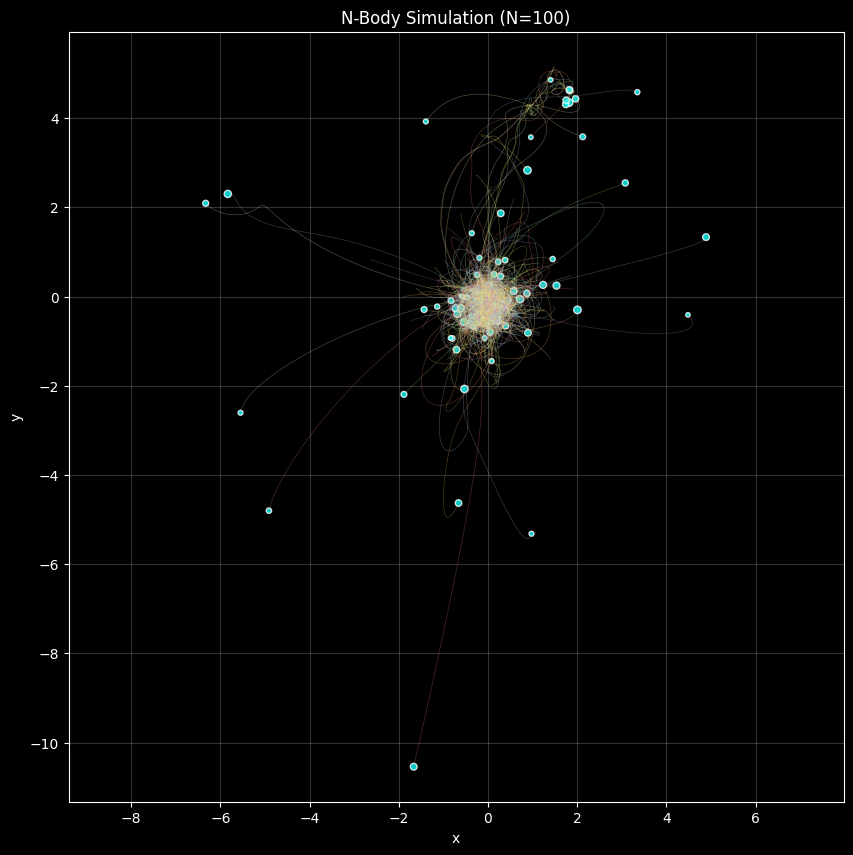

In [16]:
def run_simulation(N=100, steps=200, dt=0.01):
    positions, velocities, masses = generate_initial_state(N)
    
    trajectory_history = []
    trajectory_history.append(positions.copy())
    
    start_time = time.time()
    
    for _ in range(steps):
        # Calculate forces
        acc = calculate_accelerations(positions, masses, G, PARAM)
        
        # Integrate
        positions, velocities = symplectic_euler_step(positions, velocities, acc, dt)
        
        # Store history
        trajectory_history.append(positions.copy())
        
    end_time = time.time()
    print(f"Simulation of {N} particles for {steps} steps took: {end_time - start_time:.4f}s")
    
    return np.array(trajectory_history), masses

# Main Simualtion
history, masses = run_simulation(N=N_PARTICLES, steps=STEPS, dt=DT)

plt.figure(figsize=(10, 10))
plt.style.use('dark_background')

for i in range(N_PARTICLES):
    plt.plot(history[:, i, 0], history[:, i, 1], alpha=0.3, lw=0.5)

# Plot final positions
plt.scatter(history[-1, :, 0], history[-1, :, 1], s=masses*20, c='cyan', alpha=0.8, edgecolors='white')

plt.title(f"N-Body Simulation (N={N_PARTICLES})")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.2)
plt.axis('equal')
plt.show()

## Conservation of Energy

A good physics simulation must conserve energy. 
* **Kinetic Energy (T):** $T = \frac{1}{2} \sum m_i v_i^2$
* **Potential Energy (U):** $U = -\frac{1}{2} \sum_i \sum_{j \neq i} \frac{G m_i m_j}{r_{ij}}$

**Note that the energy functions can also change depending on how you chose the parameter, so if you make any such modification, explain that clearly.**

**Task:** Implement the energy calculation.

In [11]:
# TODO 3: Calculate the Total Energy (Kinetic + Potential).

def calculate_total_energy(positions, velocities, masses, G=1.0, param=0.1):
    # TODO 3.1: Calculate Kinetic Energy
    vel_sq = np.sum(velocities**2, axis=1)
    T = 0.5 * np.sum(masses * vel_sq)
    # print(T)
    
    # TODO 3.2: Calculate Potential Energy
    N = len(masses)
    # NOTE: using sqrt(r_ij^2 + epsilon^2) in denom

    r_vec = positions[np.newaxis,:,:] - positions[:,np.newaxis,:]
    r_sq = np.sum(r_vec**2, axis=2)
    r_adj = np.sqrt(r_sq + param**2)
    np.fill_diagonal(r_adj, np.inf) # to make self terms zero later
    mmat = masses[np.newaxis,:] * masses[:,np.newaxis]
    # print(mmat)
    # print(r_adj)
    # print(mmat / r_adj)

    # potential energy double-sum
    U = -0.5 * G * np.sum(mmat / r_adj)

    return T + U

# Test for a simple 2-body static case
pos_test = np.array([[1.0, 0.0], [-1.0, 0.0]])
vel_test = np.array([[0.0, 0.0], [0.0, 0.0]])
mass_test = np.array([1.0, 1.0])

E_check = calculate_total_energy(pos_test, vel_test, mass_test, G=1.0, param=0.0)
print(f"Test Case Energy: {E_check:.4f} (Expected: -0.2500)")

# NOTE: I think the expected val should be -0.5 and this is an error

Test Case Energy: -0.5000 (Expected: -0.2500)


## Advanced Integration with SciPy

In computational physics, we often use established libraries to verify our manual implementations. SciPy's `solve_ivp` is a powerful integrator with adaptive time-stepping.

**The Challenge:** `solve_ivp` requires the system state to be a **1D array**. You currently have 2D arrays for positions and velocities.

**TODO:**
1.  Flatten your initial `positions` and `velocities` into a single 1D array `y0`.
2.  Implement the derivative function `nbody_ode(t, y, masses, ...)` which:
    * Unpacks the 1D `y` back into `positions` and `velocities`.
    * Calculates `accelerations` using your function from Task 1.
    * Returns the derivatives (velocities and accelerations) as a flattened 1D array.
3.  Run the solver.

## 8. Task 4: Advanced Integration with SciPy

In computational physics, we often use established libraries to verify our manual implementations. SciPy's `solve_ivp` is the industry standard for solving ODEs. 

But `solve_ivp` requires the system state to be a **single 1D array**, but your physics simulation uses separate 2D arrays for position and velocity.

**Task:**
2.  Run the simulation using `solve_ivp`.

In [ ]:
from scipy.integrate import solve_ivp

# TODO 4: Implement a function nbody_ode that bridges the gap between scipy 1D requirement and your 2D logic.

def nbody_ode(t, y, masses, G):
    """
    This function takes in
        t: float, current time
        y: 1D numpy array, current state vector
        masses: (N,) array
        G: float

    This should return an array (dydt) i.e.
        1D numpy array, which time derivative of the state vector
    """
    
    # TODO 4.1: Unpack the 1D state vector 'y' into positions (N, 2) and velocities (N, 2)
    N = len(masses)
    positions = y[:2*N].reshape(N, 2)  # reshape is a view
    velocities = y[2*N:].reshape(N, 2)
    
    # TODO 4.2: Calculate accelerations
    # Hint: you can reuse your previous functio)
    accelerations = calculate_accelerations(positions, masses, G, PARAM)
    
    # TODO 4.3: Pack the derivatives (velocities and accelerations) back into a 1D array
    dydt = np.concatenate([velocities.reshape(-1), accelerations.reshape(-1)])
    
    return dydt

In [33]:
# TODO 5: Run the simulation using solve_ivp.

N_SCIPY = 10
pos_s, vel_s, mass_s = generate_initial_state(N_SCIPY)
t_span = (0, 2.0)
print(f"Running SciPy Integrator for N={N_SCIPY}...")

# TODO 5.1: Prepare the initial 1D state vector 'y0' from pos_s and vel_s
y0 = np.concatenate([pos_s.reshape(-1), vel_s.reshape(-1)])

# TODO 5.2: Call solve_ivp
sol = solve_ivp(
    fun=lambda t, y: nbody_ode(t, y, mass_s, G),
    t_span=t_span,
    y0=y0,
    max_step=0.01
)

# sol = None

if sol:
    print(f"SciPy solved in {len(sol.t)} steps.")
    print(f"Final shape of solution: {sol.y.shape}")

Running SciPy Integrator for N=10...
SciPy solved in 201 steps.
Final shape of solution: (40, 201)


# Damped coupled oscillators

The bobs of two pendulums are connected by a spring, forming a coupled oscillator system. Real systems always have some damping, in which mechanical energy is slowly converted to heat. For this problem we model the damping as a force proportional to velocity. Assume that the spring is ideal and that the system is placed on the surface of an unknown extremely large planet. Let $\theta_1$ and $\theta_2$ denote the angles that pendulum strings make with the vertical and $t$ denote time. The equations governing the motion of the system can be written as

$$ \frac{d^2 \theta_1}{d t^2} = -c_1 \frac{d \theta_1}{d t} - k_1 \theta_1 -k_c (\theta_1 - \theta_2)$$
$$ \frac{d^2 \theta_2}{d t^2} = -c_2 \frac{d \theta_2}{d t} - k_1 \theta_2 -k_c (\theta_2 - \theta_1)$$

The file `data.csv` provides you measurements for $\theta_1$ and $\theta_2$ with time. Your task is to find $c_1, c_2, k_1, k_2, k_c$ using python (numpy and/or pandas). Note that the data might have noise and also be partially corruped due to limitations of measuring instruments.  Plot the values of $\theta_1$ and $\theta_2$ predicted using the constants calculated above against the measured values. Assume arbitrary (but consistent) unit system.

In [ ]:
# Give the code you used for this here.
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares

def ode_w_sens(t, z, p):
    """
    z = [x, S.flatten()] where:
    x: shape (4,)
    S: shape (4,5)
    p: parameters = (c1,c2,k1,k2,kc)
    """
    c1, c2, k1, k2, kc = p
    x = z[:4]
    S = z[4:].reshape(4, 5)

    theta1, theta2, v1, v2 = x

    # f(x,p)
    f = np.zeros(4)
    f[0] = v1
    f[1] = v2
    f[2] = -c1*v1 - k1*theta1 - kc*(theta1 - theta2)
    f[3] = -c2*v2 - k2*theta2 - kc*(theta2 - theta1)

    # f_x
    fx = np.array([
        [0,     0,      1,      0],
        [0,     0,      0,      1],
        [-(k1+kc), kc,  -c1,    0],
        [kc, -(k2+kc),  0,     -c2]
    ])

    # f_p
    fp = np.array([
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [-v1, 0, -theta1, 0, -(theta1 - theta2)],
        [0, -v2, 0, -theta2, -(theta2 - theta1)]
    ])

    # Sensitivity evolution:  dS/dt = f_x S + f_p
    dS = fx @ S + fp

    # Return flattened augmented derivative
    return np.concatenate([f, dS.flatten()])


def integrate(t_eval, p, x0):
    S0 = np.zeros((4, 5))
    z0 = np.concatenate([x0, S0.flatten()])
    
    sol = solve_ivp(
        fun=lambda t, z: ode_w_sens(t, z, p),
        t_span=(t_eval[0], t_eval[-1]),
        y0=z0,
        t_eval=t_eval,
        rtol=1e-9,
        atol=1e-9
    )

    X = sol.y[:4]                      # (4, n_times)
    S = sol.y[4:].reshape(4, 5, -1)    # (4, 5, n_times)
    return X, S


def residuals_and_jac(p, t_eval, data, x0):
    """
    data : array shape (n_times, 2) containing theat1, tjeta2 measurements.
    """
    X, S = integrate(t_eval, p, x0)
    
    theta_pred = X[0:2].T        # (n_times, 2)
    r = (theta_pred - data).ravel()

    # Jacobian: each row = sensitivities of th1,th2 at that time
    # J = S[:2, :, :t_eval]
    J = []
    for i in range(len(t_eval)):
        Si = S[:, :, i]      # shape (4,5)
        J.append(Si[0])      # dth1/dp
        J.append(Si[1])      # dth2/dp
    J = np.vstack(J)
    return r, J


def fun_wrapper(p, t_eval, data, x0):
    r, _ = residuals_and_jac(p, t_eval, data, x0)
    return r


def jac_wrapper(p, t_eval, data, x0):
    _, J = residuals_and_jac(p, t_eval, data, x0)
    return J


def fit(t_eval, data, x0, p0):
    """
    p0: initial guess for (c1,c2,k1,k2,kc)
    """
    res = least_squares(
        fun_wrapper,
        p0,
        jac=jac_wrapper,
        args=(t_eval, data, x0),
        method="trf",
        loss="huber",
        bounds=(   # prevents this from returning invalid values
            [0,0,0,0,0],
            [np.inf, np.inf, np.inf, np.inf, np.inf]
        )
    )
    return res.x, res



In [27]:
data_raw = np.loadtxt("data.csv", delimiter=",", skiprows=1)

t_eval = data_raw[:, 0]
data   = data_raw[:, 1:3]
print("Time span:", t_eval[0], t_eval[-1])
print("Data shape:", data.shape)

# initial cond
theta10, theta20 = data[0]
v10, v20 = 0.0, 0.0 # assuming
x0 = np.array([theta10, theta20, v10, v20])

Time span: 0.0008042852762035337 50.0
Data shape: (50000, 2)


In [28]:
p0 = np.array([0.1, 0.1, 1.0, 1.0, 0.1])

p_est, result = fit(t_eval, data, x0, p0)

print("Estimated parameters = ", p_est)
print("Optimizer success: ", result.success)
print("Message:", result.message)

Estimated parameters =  [0.11739277 0.04116784 2.01684673 2.99013428 3.99991234]
Optimizer success:  True
Message: `ftol` termination condition is satisfied.


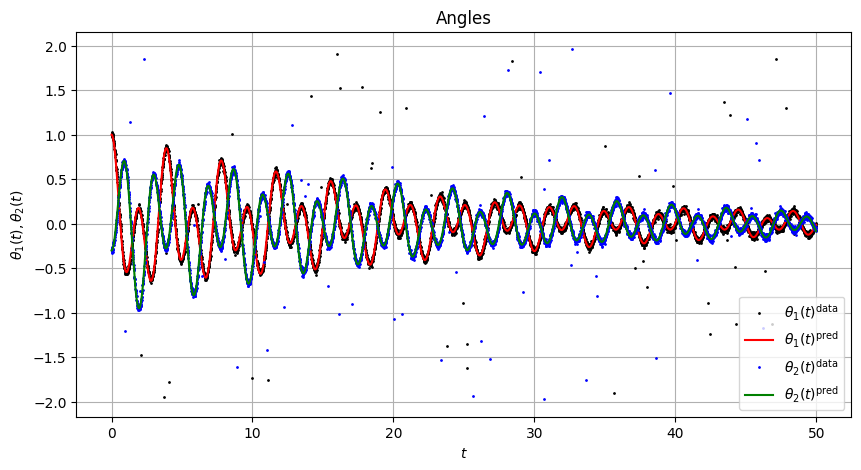

In [33]:
# PLOTTING THETA
X_pred, _ = integrate(t_eval, p_est, x0)

theta1_pred = X_pred[0]
theta2_pred = X_pred[1]
v1_pred     = X_pred[2]
v2_pred     = X_pred[3]

theta1_data = data[:,0]
theta2_data = data[:,1]

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

# plotting every 10th tick to prevent clutter

plt.plot(t_eval[::10], theta1_data[::10], 'k.', markersize=2, label=r"$\theta_1(t)^{\text{data}}$")
plt.plot(t_eval[::10], theta1_pred[::10], 'r-', linewidth=1.5, label=r"$\theta_1(t)^{\text{pred}}$")

plt.plot(t_eval[::10]
         , theta2_data[::10], 'b.', markersize=2, label=r"$\theta_2(t)^{\text{data}}$")
plt.plot(t_eval[::10], theta2_pred[::10], 'g-', linewidth=1.5, label=r"$\theta_2(t)^{\text{pred}}$")

plt.xlabel(r"$t$")
plt.ylabel(r"$\theta_1(t), \theta_2(t)$")
plt.title("Angles")
plt.legend()
plt.grid(True)

plt.show()


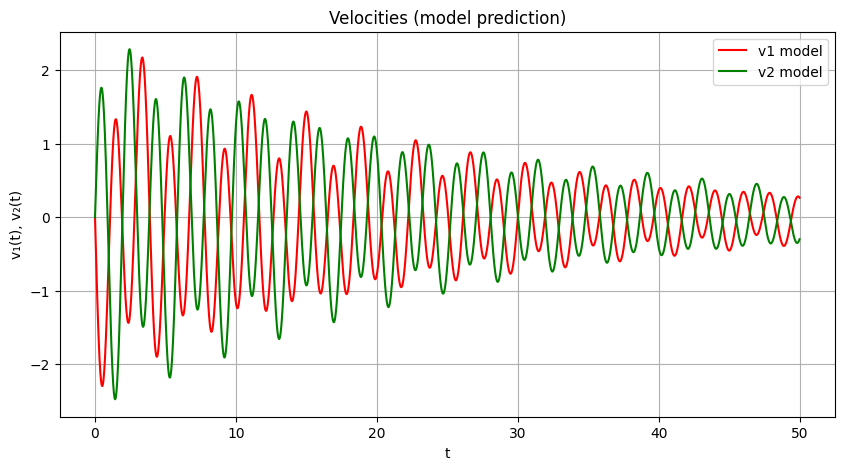

In [32]:
plt.figure(figsize=(10,5))

plt.plot(t_eval, v1_pred, 'r-', linewidth=1.5, label="v1 model")
plt.plot(t_eval, v2_pred, 'g-', linewidth=1.5, label="v2 model")

plt.xlabel("t")
plt.ylabel("v₁(t), v₂(t)")
plt.title("Velocities (model prediction)")
plt.legend()
plt.grid(True)

plt.show()


## Explanation

I attempt simple least-squares fit on the predicted values for $\theta_1, \theta_2$ (after numerical integration). I explore an idea called *sensitivity augmenting* where I augment the ODE with the Jacobians w.r.t parameters $p = (c_1, c_2, k_1, k_2, k_c)$ coz those ODEs can be solved simultaneously and used for gradient descent directly.

$$
x = (\theta_1 \; \theta_2 \; \dot{\theta_1} \; \dot{\theta_2})^\top, \quad \dot{x} = f(x,p), \quad S(t) = \partial x(t)/ \partial p \in \mathbb{R}^{4\times 5} \\

f(x,p) = \begin{pmatrix} \dot{\theta_1} \\ \dot{\theta_2} \\ -c_1\dot{\theta_1} - k_1\theta_1 - k_c(\theta_1-\theta_2) \\ -c_2\dot{\theta_2} - k_2\theta_2 - k_c(\theta_2-\theta_1) \end{pmatrix}
$$

Augmented ODE:
$$
\frac{d}{dt} \begin{pmatrix} x \\ S \end{pmatrix}
= \begin{pmatrix} f(x,p) \\ f_x(x,p)S + f_p(x,p) \end{pmatrix}
$$

where $f_x, f_p$ are Jacobians of original ODE wrt $x,p$. In code
```python
# f_x
fx = np.array([
    [0,     0,      1,      0],
    [0,     0,      0,      1],
    [-(k1+kc), kc,  -c1,    0],
    [kc, -(k2+kc),  0,     -c2]
])

# f_p
fp = np.array([
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [-v1, 0, -theta1, 0, -(theta1 - theta2)],
    [0, -v2, 0, -theta2, -(theta2 - theta1)]
])
```

Using [`scipy.optimize.least_squares`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.least_squares.html), and `method='trf'` (Default) and `loss='huber'` coz its more robust. Originally I was seeing convergence to some physically impossible local minima ($k_c<0$) so I added robust loss and bounding.


### Other Ideas

- The first idea that comes up is naive finite differences to compute time derivatives and then linear regression. But the corrupt data invalidates this -- error would magnify in finite differences especially second order differences.

- Another idea to avoid *finite difference*-induced error blowup is to work in ODE (particular) solution space -- <br>
*solve the ODE system analytically (linear combination of decaying sine waves i believe) and then solve for the parameters* <br>This isn't feasible in general coz of the high nonlinearity (we'd be optimizing for $\alpha, \omega, \phi$ in $A_i e^{-\alpha_i t} \cos(\omega_i t + \phi_i)) and mapping those parameters to $c_1,c_2,k_1,k_2,k_c$ would be messy as well.

- We can avoid all this hassle by working directly in parameter space doing a least squares fit. <br>
  The key insight is that differentiating w.r.t parameters gives a linear ODE in terms of $S$ (jacobian of state variables wrt parameters) which is exactly what the LS optimizer will need. <br>
  So we can add those to the existing ODE equations, during forward integration compute those as well, and feed the whole thing to the LS optimizer. <br>
  It runs in ~20s on my system right now.